# Demo usando PySR

## Librerías


In [1]:
import pysr

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
from julia import CUDA
print(CUDA.versioninfo())

CUDA toolchain: 
- runtime 12.9, artifact installation
- driver 571.96.0 for 12.8
- compiler 12.9

CUDA libraries: 
- CUBLAS: 12.9.1
- CURAND: 10.3.10
- CUFFT: 11.4.1
- CUSOLVER: 11.7.5
- CUSPARSE: 12.5.10
- CUPTI: 2025.2.1 (API 28.0.0)
- NVML: 12.0.0+571.96

Julia packages: 
- CUDA: 5.8.3
- CUDA_Driver_jll: 13.0.1+0
- CUDA_Compiler_jll: 0.2.1+0
- CUDA_Runtime_jll: 0.19.1+0

Toolchain:
- Julia: 1.11.7
- LLVM: 16.0.6

1 device:
None
  0: NVIDIA GeForce RTX 3050 Laptop GPU (sm_86, 3.871 GiB / 4.000 GiB available)


In [7]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

tqdm.pandas()

# Simple PySR example:


First, let's learn a simple function

$$2.5382 \cos(x_3) + x_0^2 - 2$$

In [4]:
# Dataset
np.random.seed(0)
X = 2 * np.random.randn(100, 5)
y = 2.5382 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 2

By default, we will set up 30 populations of expressions (which evolve independently except for migrations), use 4 threads, and use `"best"` for our model selection strategy:

In [5]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

PySR can run for arbitrarily long, and continue to find more and more accurate expressions. You can set the total number of cycles of evolution with `niterations`, although there are also a [few more ways](https://github.com/MilesCranmer/PySR/pull/134) to stop execution.

**This first execution will take a bit longer to startup, as the library is JIT-compiled. The next execution will be much faster.**

In [8]:
# Learn equations
model = PySRRegressor(
    niterations=30,
    binary_operators=["+", "*"],
    unary_operators=["cos", "exp", "sin"],
    progress=True,
    **default_pysr_params,
)

model.fit(X, y)

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.360e+01  0.000e+00  y = 2.3551
3           6.128e+00  8.509e-01  y = x₀ * x₀
5           3.045e+00  3.496e-01  y = (x₀ * x₀) + -1.7558
7           3.030e+00  2.620e-03  y = (x₀ * (x₀ * 0.97769)) + -1.664
8           1.118e+00  9.964e-01  y = (cos(x₃) + (x₀ * x₀)) + -1.852
10          2.029e-13  1.467e+01  y = ((cos(x₃) * 2.5382) + (x₀ * x₀)) + -2
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs\20250917_145702_GVrqjU\hall_of_fame.csv


[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,"['cos', 'exp', ...]"
,expression_spec,None
,niterations,30
,populations,30
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


We can print the model, which will print out all the discovered expressions:

In [9]:
model

,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,"['cos', 'exp', ...]"
,expression_spec,None
,niterations,30
,populations,30
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


We can also view the SymPy format of the best expression:

In [10]:
model.sympy()

x0*x0 + cos(x3)*2.5382 - 1.9999999

We can also view the SymPy of any other expression in the list, using the index of it in `model.equations_`.

In [11]:
model.sympy(2)

x0*x0 - 1.7557724

## Output

`model.equations_` is a Pandas DataFrame. We can export the results in various ways:

In [12]:
model.latex()

'x_{0} x_{0} + \\cos{\\left(x_{3} \\right)} 2.54 - 2.00'

These is also `model.sympy(), model.jax(), model.pytorch()`. All of these can take an index as input, to get the result for an arbitrary equation in the list.

We can also use `model.predict` for arbitrary equations, with the default equation being the one chosen by `model_selection`:

In [13]:
ypredict = model.predict(X)
ypredict_simpler = model.predict(X, 2)

print("Default selection MSE:", np.power(ypredict - y, 2).mean())
print("Manual selection MSE for index 2:", np.power(ypredict_simpler - y, 2).mean())

Default selection MSE: 1.0000000012565521e-14
Manual selection MSE for index 2: 3.0454920140929405


# Custom operators

A full list of operators is given here: https://ai.damtp.cam.ac.uk/pysr/operators,
but we can also use any binary or unary operator in `julia`, or define our own as arbitrary functions.

Say that we want a command to do quartic powers:

$$ y = x_0^4 - 2 $$

In [14]:
y = X[:, 0] ** 4 - 2

We can do this by passing a string in Julia syntax.

We also define the operator in sympy, with `extra_sympy_mappings`, to enable its use in `predict`, and other export functions.

In [15]:
model = PySRRegressor(
    niterations=5,
    populations=40,
    binary_operators=["+", "*"],
    unary_operators=["cos", "exp", "sin", "quart(x) = x^4"],
    extra_sympy_mappings={"quart": lambda x: x**4},
)
model.fit(X, y)

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.590e+04  0.000e+00  y = 46.876
2           4.000e+00  8.287e+00  y = quart(x₀)
4           1.106e-10  1.216e+01  y = quart(x₀) + -2
7           1.106e-10  6.954e-06  y = sin(2.4139e-07) + (quart(x₀) + -2)
8           1.099e-10  5.693e-03  y = (x₀ * 1.1604e-06) + (quart(x₀) + -2)
10          1.097e-10  9.497e-04  y = (((x₀ * x₀) * -4.0942e-07) + quart(x₀)) + -2
11          1.081e-10  1.514e-02  y = quart(x₀) + ((exp(x₀ * 0.94176) * 2.1388e-07) + -2)
15          7.775e-11  8.236e-02  y = (((x₀ * ((x₀ * 1.1289e-07) + quart(x₀))) * 7.9633e-09)...
                                       + quart(x₀)) + -2
20          6.722e-11  2.908e-02  y = (((x₀ * ((x₀ + -1.9212) * x₀)) * 2.1388e-07) * ((x₃ + ...
                                      x₁) * 0.30684)) + (quart(x₀) + -2)
────────────────────────────────────────────────────────────────────

,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,"['cos', 'exp', ...]"
,expression_spec,None
,niterations,5
,populations,40
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - outputs\20250917_150454_qARMkQ\hall_of_fame.csv


In [16]:
model.sympy()

x0**4 + x0*(x0**4 + x0*1.1289433e-7)*7.963334e-9 - 1.9999979

Since `quart` is arguably more complex than the other operators, you can also give it a different complexity, using, e.g., `complexity_of_operators={"quart": 2}` to give it a complexity of 2 (instead of the default 1). You can also define custom complexities for variables and constants (`complexity_of_variables` and `complexity_of_constants`, respectively - both take a single number).


One can also add a binary operator, with, e.g., `"myoperator(x, y) = x^2 * y"`. All Julia operators that work on scalar 32-bit floating point values are available.

Make sure that any operator you add is valid over the real line. So, e.g., you will need to define `"mysqrt(x) = sqrt(abs(x))"` to enable it for negative numbers,
or, simply have it return a very large number for bad inputs (to prevent negative input in a soft way):
`"mysqrt(x::T) where {T} = (x >= 0) ? x : T(-1e9)"` (Julia syntax for a template function of input type `T`), which will make `mysqrt(x)` return -10^9 for negative x–hurting the loss of the equation.

## Scoring

Using `model_selection="best"`selects the equation with the max score and prints it. But in practice it is best to look through all the equations manually, select an equation above some MSE threshold, and then use the score to select among that loss threshold.

Here, "score" is defined by:
$$ \text{score} = - \log(\text{loss}_i/\text{loss}_{i-1})/
(\text{complexity}_i - \text{complexity}_{i-1})$$

This scoring is motivated by the common strategy of looking for drops in the loss-complexity curve.

From Schmidt & Lipson (2009) -

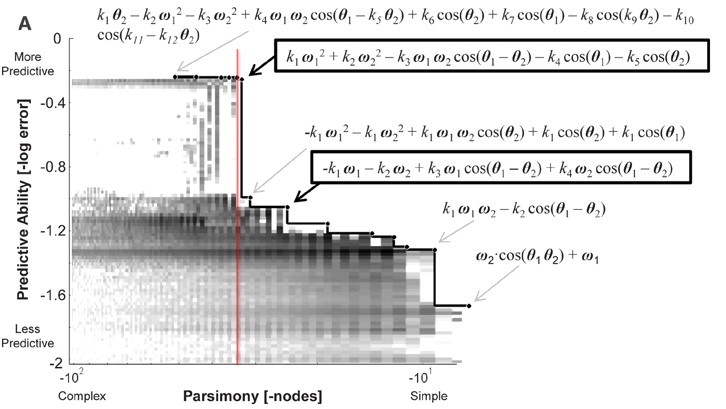

# Noise example

Here is an example with noise. Known Gaussian noise with $\sigma$ between 0.1 and 5.0. We record samples of $y$:

$$ \sigma \sim U(0.1, 5.0) $$
$$ \epsilon \sim \mathcal{N}(0, \sigma^2)$$
$$ y = 5\;\cos(3.5 x_0) - 1.3 + \epsilon.$$
We have 5 features, say. The weights change the loss function to be:
$$MSE = \sum [(y - f(x))^2*w],$$

so in this example, we can set:
$$w = 1/\sigma^2.$$

In [17]:
np.random.seed(0)
N = 3000
upper_sigma = 5
X = 2 * np.random.rand(N, 5)
sigma = np.random.rand(N) * (5 - 0.1) + 0.1
eps = sigma * np.random.randn(N)
y = 5 * np.cos(3.5 * X[:, 0]) - 1.3 + eps

Let's look at this dataset:

Text(0, 0.5, '$y$')

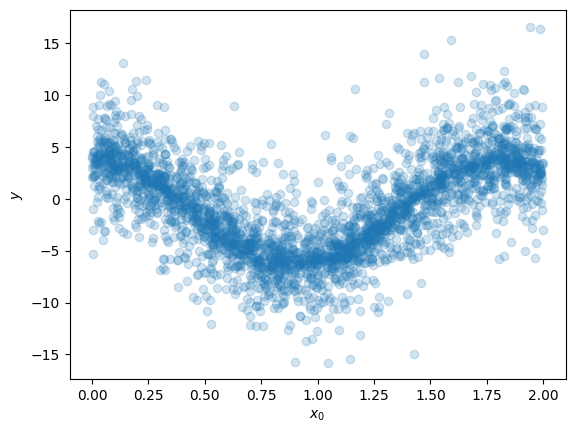

In [18]:
plt.scatter(X[:, 0], y, alpha=0.2)
plt.xlabel("$x_0$")
plt.ylabel("$y$")

Define some weights to use:

In [19]:
weights = 1 / sigma**2

In [20]:
weights[:5]

array([0.25199296, 0.0775419 , 0.11515701, 0.1781281 , 0.0448131 ])

Let's run PySR again:

In [21]:
model = PySRRegressor(
    elementwise_loss="myloss(x, y, w) = w * abs(x - y)",  # Custom loss function with weights.
    niterations=20,
    populations=20,  # Use more populations
    binary_operators=["+", "*"],
    unary_operators=["cos"],
)
model.fit(X, y, weights=weights)

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.510e+04
Progress: 225 / 400 total iterations (56.250%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.304e+00  0.000e+00  y = -1.1849
3           3.183e+00  1.860e-02  y = x₀ + -2.0866
4           2.743e+00  1.488e-01  y = cos(x₀ * -3.3334)
6           1.118e+00  4.487e-01  y = cos(x₀ * 3.2401) * 5.0368
8           3.126e-01  6.373e-01  y = (cos(x₀ * 3.496) + -0.2559) * 5.0368
11          3.126e-01  1.208e-05  y = ((cos(x₀ * 3.496) + cos(1.616)) * 5.0368) + -1.0603
12          3.126e-01  3.445e-05  y = (((cos(x₀ * 3.4957) * 7.2071) + -5.0864) * 0.69852) + ...
                                      2.2664
15          3.126e-01  9.259e-06  y = ((cos(x₀ * 3.4957) * 5.0333) + -2.2874) + cos((x₃ * x₀...
                                      ) * -0.

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,['cos']
,expression_spec,None
,niterations,20
,populations,20
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


Let's see if we get similar results to the true equation

In [22]:
model

,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,['cos']
,expression_spec,None
,niterations,20
,populations,20
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


We can also filter all equations up to 2x the most accurate equation, then select the best score from that list:

In [23]:
best_idx = model.equations_.query(
    f"loss < {2 * model.equations_.loss.min()}"
).score.idxmax()
model.sympy(best_idx)

cos(x0*3.4951167)*5.020927 - 1.2897638

We can also use `denoise=True`, which will run the input through a Gaussian process to denoise the dataset, before fitting on it.

Let's look at the fit:

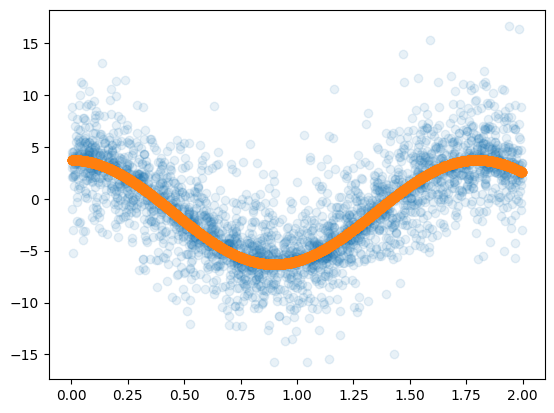

In [24]:
plt.scatter(X[:, 0], y, alpha=0.1)
y_prediction = model.predict(X, index=best_idx)
plt.scatter(X[:, 0], y_prediction)

# Multiple outputs

For multiple outputs, multiple equations are returned:

In [30]:
import os
os.environ["PYTHONINSPECT"] = "0"  # Evita que se detecte como Jupyter
from pysr import PySRRegressor
import sys
print('ipykernel' in sys.modules)

True


In [28]:
X = 2 * np.random.randn(100, 5)
y = 1 / X[:, [0, 1, 2]]

In [29]:
model = PySRRegressor(
    binary_operators=["+", "*"],
    unary_operators=["inv(x) = 1/x"],
    extra_sympy_mappings={"inv": lambda x: 1 / x},
)
model.fit(X, y)

C:\Users\matia\PycharmProjects\GE_Re_EL7037_2025\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Expressions evaluated per second: 4.490e+05
Progress: 2062 / 9300 total iterations (22.172%)
════════════════════════════════════════════════════════════════════════════════════════════════════
Best equations for output 1
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.354e+01  0.000e+00  y₀ = 1.0167
2           2.447e-14  3.577e+01  y₀ = inv(x₀)
6           2.446e-14  9.075e-05  y₀ = (x₂ * 3.3991e-09) + inv(x₀)
7           1.530e-14  4.694e-01  y₀ = inv(x₀) + (inv(x₀) * -3.2021e-08)
9           1.494e-14  1.182e-02  y₀ = (x₂ * (inv(x₀) * 9.6426e-09)) + inv(x₀)
11          5.853e-15  4.685e-01  y₀ = inv(x₀) + ((6.1522e-09 * (x₄ * x₂)) * inv(x₀))
13          5.766e-15  7.453e-03  y₀ = inv(x₀) + ((6.1522e-09 * (x₄ * (x₂ + x₀))) * inv(x₀)...
                                       )
15          5.720e-15  4.060e-03  y₀ = (((x₄ * -0.12078) + -0.020336) * (x₂ * (inv(x₀) * -4...
     

[ Info: Started!
[ Info: Final populations:
[ Info: Output 1:
[ Info: Output 2:
[ Info: Output 3:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,['inv(x) = 1/x']
,expression_spec,None
,niterations,100
,populations,31
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


In [ ]:
model

# Julia packages and types

PySR uses [SymbolicRegression.jl](https://github.com/MilesCranmer/SymbolicRegression.jl)
as its search backend. This is a pure Julia package, and so can interface easily with any other
Julia package.
For some tasks, it may be necessary to load such a package.

For example, let's say we wish to discovery the following relationship:

$$ y = p_{3x + 1} - 5, $$

where $p_i$ is the $i$th prime number, and $x$ is the input feature.

Let's see if we can discover this using
the [Primes.jl](https://github.com/JuliaMath/Primes.jl) package.



`jl` stores the Julia runtime.

Now, let's run some Julia code to add the Primes.jl
package to the PySR environment:

In [ ]:
from pysr import jl

jl.seval(
    """
import Pkg
Pkg.add("Primes")
"""
)

This imports the Julia package manager, and uses it to install
`Primes.jl`. Now let's import `Primes.jl`:

In [ ]:
jl.seval("using Primes: prime")

Note that PySR should automatically load the `juliacall.ipython` extension for you,
which means that you can also execute Julia code in the notebook using the `%%julia` magic:

In [ ]:
%julia using Primes: prime


Now, we define a custom operator:


In [ ]:
jl.seval(
    """
function p(i::T) where T
    if 0.5 < i < 1000
        return T(prime(round(Int, i)))
    else
        return T(NaN)
    end
end
"""
)


We have created a function `p`, which takes a number `i` of type `T` (e.g., `T=Float64`).
`p` first checks whether the input is between 0.5 and 1000.
If out-of-bounds, it returns `NaN`.
If in-bounds, it rounds it to the nearest integer, computes the corresponding prime number, and then
converts it to the same type as input.

The equivalent function in Python would be:

```python
import sympy

def p(i):
    if 0.5 < i < 1000:
        return float(sympy.prime(int(round(i))))
    else:
        return float("nan")
```

(However, note that this version assumes 64-bit float input, rather than any input type `T`)

Next, let's generate a list of primes for our test dataset.
Since we are using juliacall, we can just call `p` directly to do this:


In [ ]:
primes = {i: jl.p(i * 1.0) for i in range(1, 999)}

Next, let's use this list of primes to create a dataset of $x, y$ pairs:

In [ ]:
import numpy as np

X = np.random.randint(0, 100, 100)[:, None]
y = [primes[3 * X[i, 0] + 1] - 5 + np.random.randn() * 0.001 for i in range(100)]

Note that we have also added a tiny bit of noise to the dataset.

Finally, let's create a PySR model, and pass the custom operator. We also need to define the sympy equivalent, which we can leave as a placeholder for now:

In [ ]:
from pysr import PySRRegressor
import sympy


class sympy_p(sympy.Function):
    pass


model = PySRRegressor(
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["p"],
    niterations=20,
    extra_sympy_mappings={"p": sympy_p},
)

We are all set to go! Let's see if we can find the true relation:

In [ ]:
model.fit(X, y)

if all works out, you should be able to see the true relation (note that the constant offset might not be exactly 1, since it is allowed to round to the nearest integer).

You can get the sympy version of the best equation with:

In [ ]:
model.sympy()